<a href="https://www.kaggle.com/code/lalit7881/flight-ticket-pricing-data?scriptVersionId=302115733" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/airline-ticket-prices-dataset/airline_ticket_prices_dataset.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/airline-ticket-prices-dataset/airline_ticket_prices_dataset.csv")

In [3]:
df.head()

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19


In [4]:
df.tail()

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
245,246,Qatar Airways,Cairo,Paris,2389,First,33,1513.01
246,247,Turkish Airlines,Dubai,Paris,6941,First,36,4298.76
247,248,Saudia,Doha,London,7396,Business,34,3008.26
248,249,Lufthansa,Riyadh,Istanbul,8028,Business,58,2540.92
249,250,Emirates,Paris,New York,11507,Economy,72,1525.20


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              250 non-null    int64  
 1   Airline                250 non-null    object 
 2   Origin                 250 non-null    object 
 3   Destination            250 non-null    object 
 4   Distance_km            250 non-null    int64  
 5   Class                  250 non-null    object 
 6   Days_Before_Departure  250 non-null    int64  
 7   Price_USD              250 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 15.8+ KB


In [6]:
df.describe()

,Ticket_ID,Distance_km,Days_Before_Departure,Price_USD
count,250.000000,250.000000,250.000000,250.000000
mean,125.500000,5999.952000,59.024000,2006.059760
std,72.312977,3401.695261,33.736628,1675.067217
min,1.000000,336.000000,1.000000,106.070000
25%,63.250000,2991.750000,31.250000,818.665000
50%,125.500000,6132.500000,60.500000,1531.235000
75%,187.750000,8832.750000,86.750000,2590.357500
max,250.000000,11903.000000,118.000000,8852.690000


In [7]:
df.dtypes

Ticket_ID                  int64
Airline                   object
Origin                    object
Destination               object
Distance_km                int64
Class                     object
Days_Before_Departure      int64
Price_USD                float64
dtype: object

In [8]:
df.shape

(250, 8)

In [9]:
df.columns

Index(['Ticket_ID', 'Airline', 'Origin', 'Destination', 'Distance_km', 'Class',
       'Days_Before_Departure', 'Price_USD'],
      dtype='object')

In [10]:
df.isnull().sum()

Ticket_ID                0
Airline                  0
Origin                   0
Destination              0
Distance_km              0
Class                    0
Days_Before_Departure    0
Price_USD                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

Ticket_ID                250
Airline                    8
Origin                    10
Destination               10
Distance_km              249
Class                      3
Days_Before_Departure    106
Price_USD                250
dtype: int64

## Data visualizations

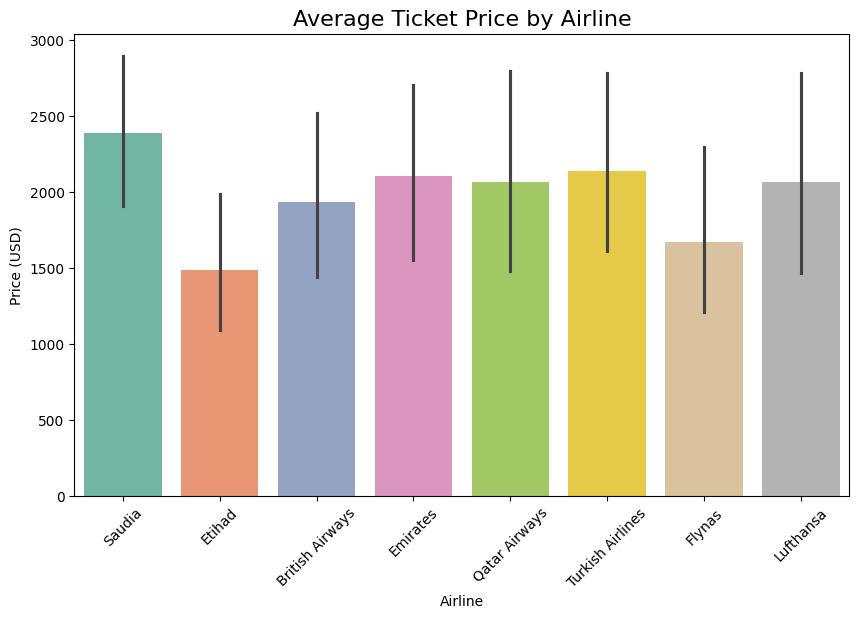

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Airline',
    y='Price_USD',
    data=df,
    palette='Set2'
)

plt.title("Average Ticket Price by Airline", fontsize=16)
plt.xlabel("Airline")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)

plt.show()

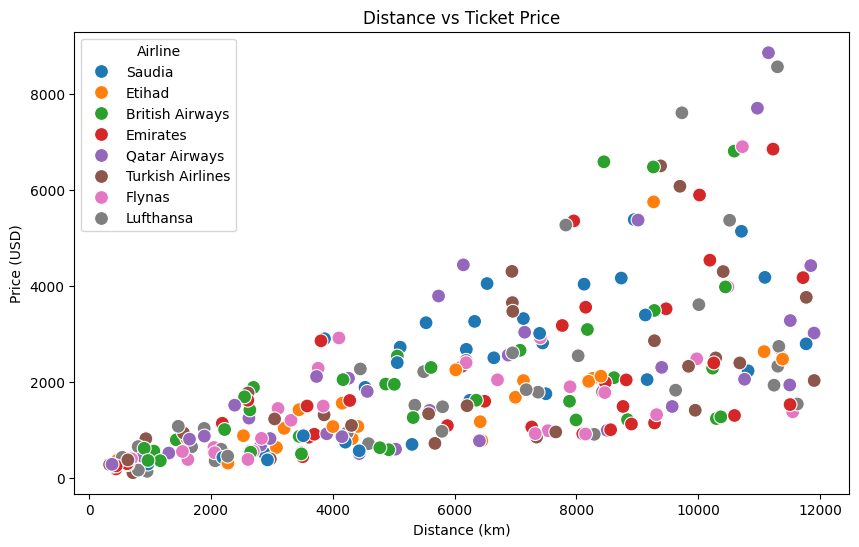

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Distance_km',
    y='Price_USD',
    hue='Airline',
    palette='tab10',
    data=df,
    s=100
)

plt.title("Distance vs Ticket Price")
plt.xlabel("Distance (km)")
plt.ylabel("Price (USD)")

plt.show()

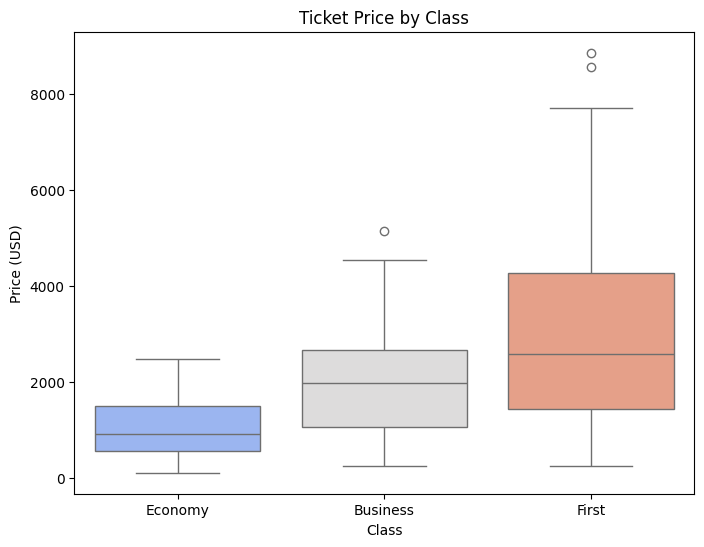

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Class',
    y='Price_USD',
    data=df,
    palette='coolwarm'
)

plt.title("Ticket Price by Class")
plt.xlabel("Class")
plt.ylabel("Price (USD)")

plt.show()

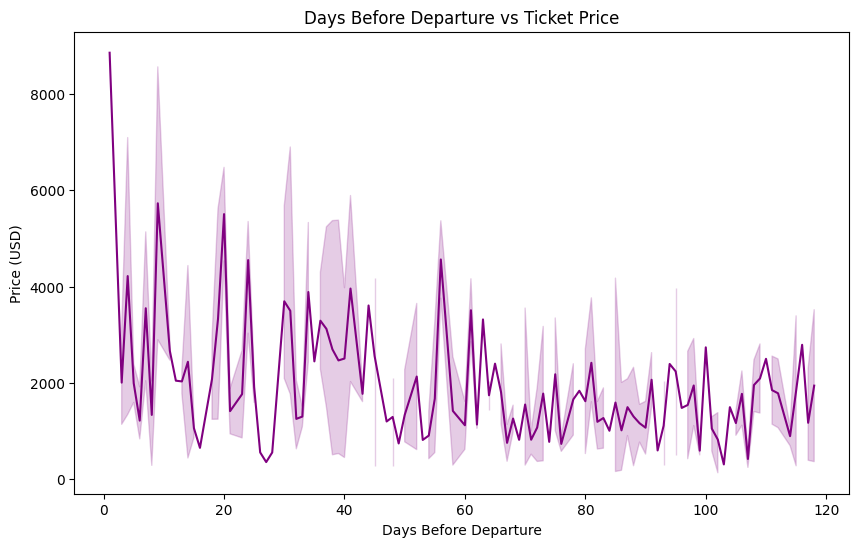

In [16]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x='Days_Before_Departure',
    y='Price_USD',
    data=df,
    color='purple'
)

plt.title("Days Before Departure vs Ticket Price")
plt.xlabel("Days Before Departure")
plt.ylabel("Price (USD)")

plt.show()

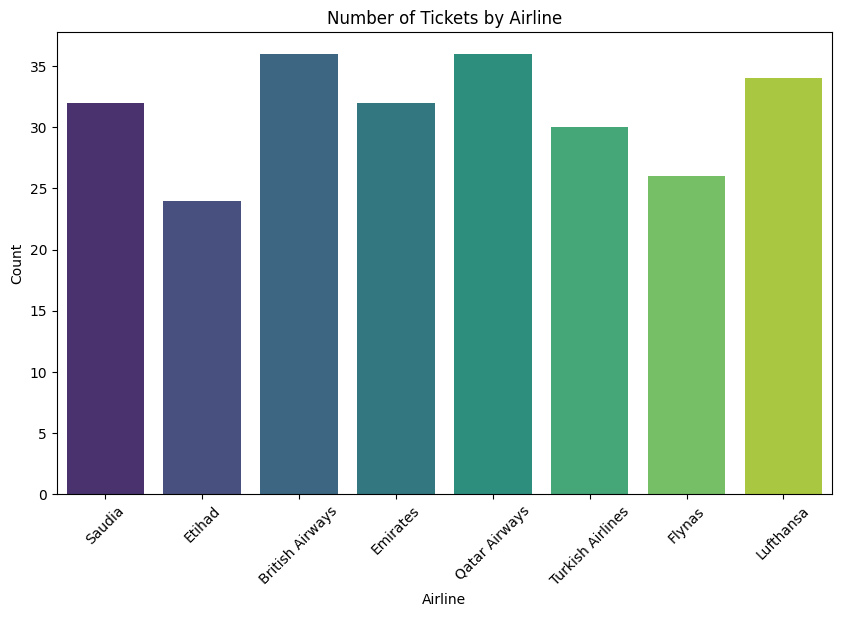

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Airline',
    data=df,
    palette='viridis'
)

plt.title("Number of Tickets by Airline")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

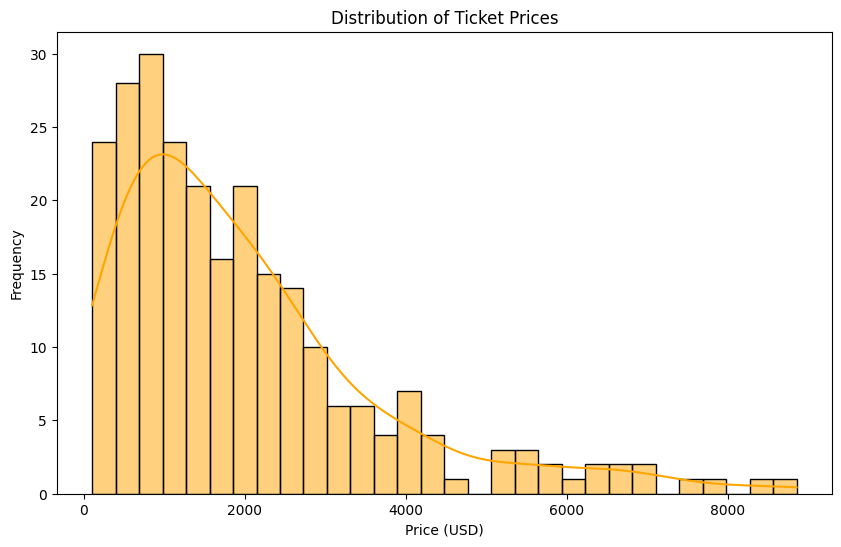

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Price_USD'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Distribution of Ticket Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

plt.show()

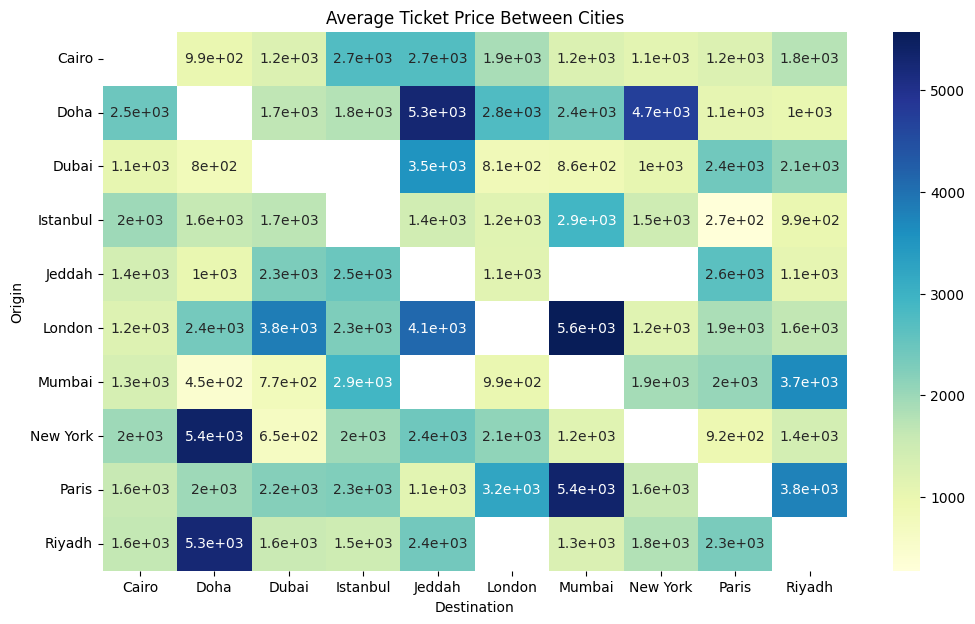

In [19]:
pivot = df.pivot_table(
    values='Price_USD',
    index='Origin',
    columns='Destination',
    aggfunc='mean'
)

plt.figure(figsize=(12,7))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=True
)

plt.title("Average Ticket Price Between Cities")

plt.show()

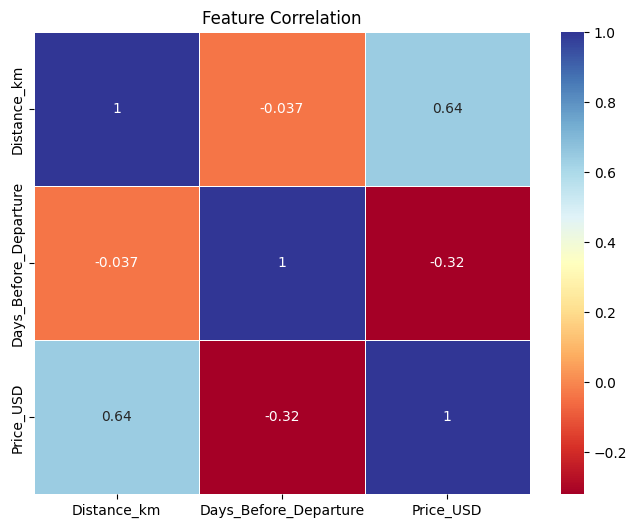

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Distance_km','Days_Before_Departure','Price_USD']].corr(),
    annot=True,
    cmap='RdYlBu',
    linewidths=0.5
)

plt.title("Feature Correlation")

plt.show()


## Feature engineering

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [22]:
df['Price_Category'] = pd.qcut(df['Price_USD'], q=3, labels=['Low','Medium','High'])

print(df[['Price_USD','Price_Category']].head())

   Price_USD Price_Category
0     555.30            Low
1    2070.27         Medium
2    1883.11         Medium
3    5349.65           High
4     516.19            Low


In [23]:
df = df.drop(['Ticket_ID','Price_USD'], axis=1)

In [24]:
le = LabelEncoder()

categorical_columns = ['Airline','Origin','Destination','Class','Price_Category']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [25]:
X = df.drop('Price_Category', axis=1)
y = df['Price_Category']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "SVM": SVC(probability=True),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}


MODEL : Logistic Regression
Accuracy : 48.0 %


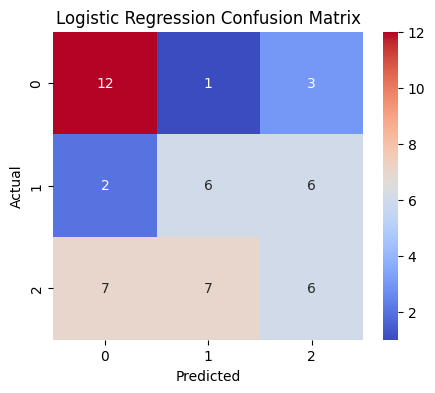

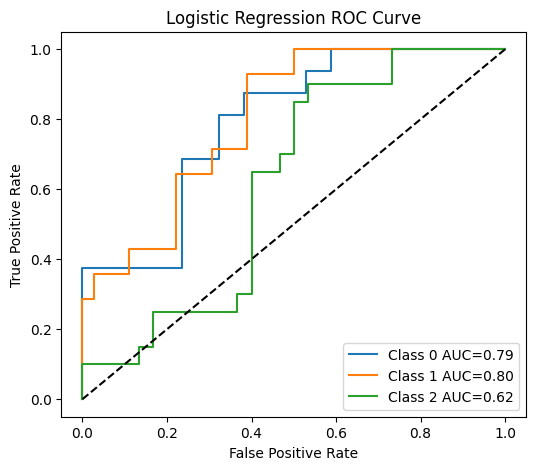


MODEL : Decision Tree
Accuracy : 88.0 %


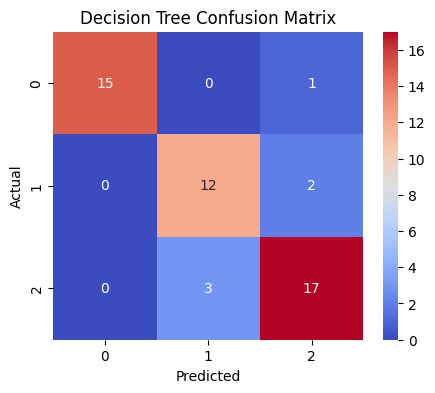

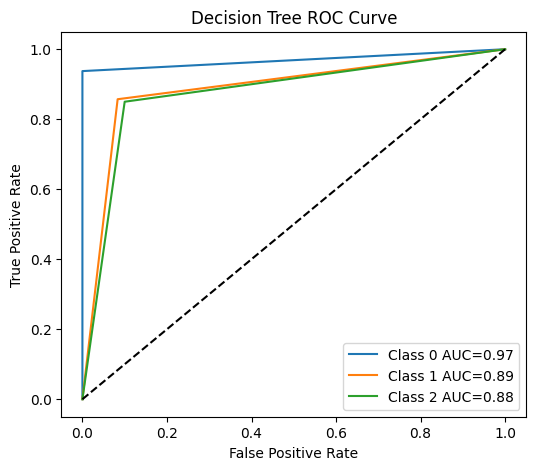


MODEL : Random Forest
Accuracy : 88.0 %


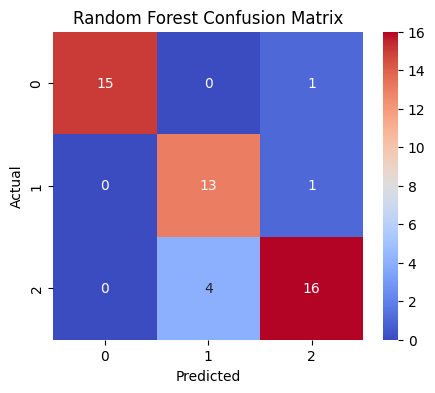

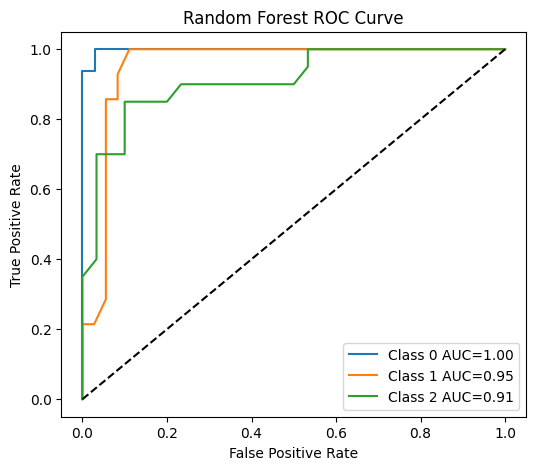


MODEL : SVM
Accuracy : 52.0 %


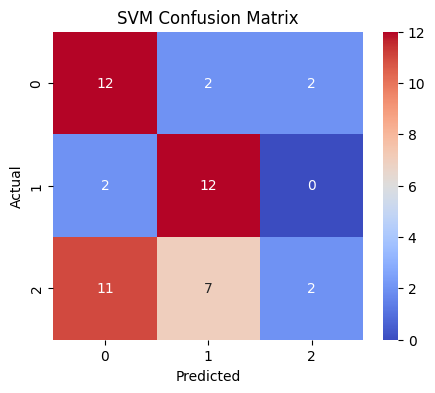

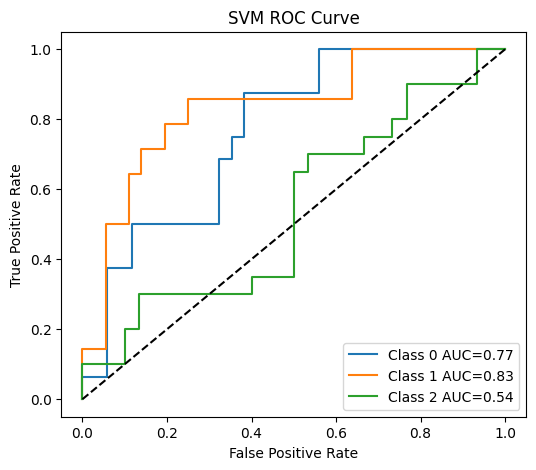


MODEL : KNN
Accuracy : 52.0 %


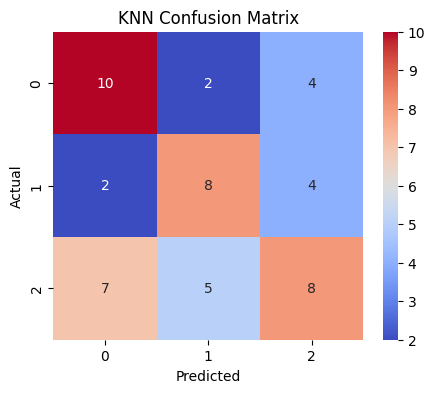

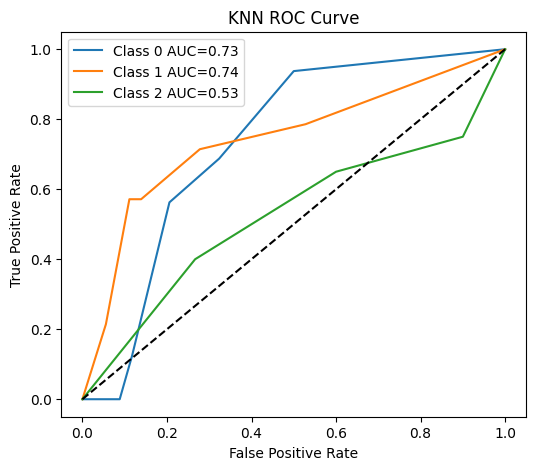


MODEL : Naive Bayes
Accuracy : 58.0 %


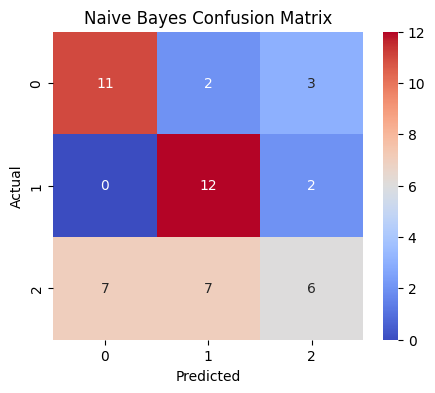

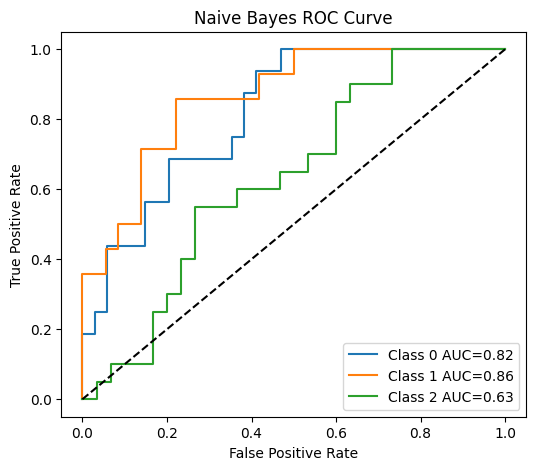

In [28]:
for name, model in models.items():

    print("\n"+"="*60)
    print("MODEL :", name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)*100

    print("Accuracy :", round(acc,2), "%")


    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # ROC Curve

    y_prob = model.predict_proba(X_test)

    y_test_bin = label_binarize(y_test, classes=[0,1,2])

    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(6,5))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])

        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")

    plt.plot([0,1],[0,1],'k--')

    plt.title(f"{name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.show()

## Thank you...pls upvote!!!!!!!!